# Traductor LSP → Castellano — Entrega Final Semana 15

**Proyecto:** Sistema integral de traducción automática de Lengua de Señas Peruana (LSP) a texto en castellano mediante Deep Learning
**Autor:** Juan Calla
**Fecha:** 2026-07-24
**Estado:** sistema funcionando de punta a punta, validado con datos reales — modelo activo: ensemble BiLSTM S27(v4) + S29

> Este documento consolida el estado real del proyecto a la fecha, verificado contra el código y los datos del repositorio — no hay cifras estimadas. Fuentes primarias: `logs/runs.csv` (33 sprints), `ENTREGABLE_PLAN_DE_DESPLIEGUE_S13.md` (§1-§14, historial detallado de riesgos R1-R15), `RESULTADOS_PRESENTACION_S15.md` (resultados de modelo), y los reportes JSON de cada corrida (`data/*_he3_report.json`, `data/s3*_wer_resultados.json`).

---

**Funciones auxiliares** — usadas en las celdas de *análisis* del Anexo (no en los gráficos, que son 100% independientes y traen su propio cálculo de IC inline).

In [1]:
import math

def wilson(k, n, z=1.96):
    """Intervalo de confianza Wilson 95% para una proporción k/n."""
    p = k / n
    denom = 1 + z**2 / n
    centre = p + z**2 / (2 * n)
    adj = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return p, max(0, (centre - adj) / denom), min(1, (centre + adj) / denom)

## 1. Resumen ejecutivo

### Objetivos del proyecto — estado

| Objetivo | Estado | Evidencia |
|---|---|---|
| 1. Alta precisión | ⚠ Mejor histórico | F1-macro=0.4426 (test); meta declarada F1>0.70 no alcanzada — ese número era de planificación temprana para ≥200 clases, no comparable |
| 2. Latencia <200ms | ✓ Cumplido | Modelo: 0.6–0.9ms · Pipeline E2E real (WebSocket): p50=54.7ms / p95=58.7ms |
| 3. Sistema integral | ✓ Núcleo funcional | Demo+API+deploy validados en vivo con datos reales; 6/6 tests |

El sistema traduce en tiempo real señas aisladas de un vocabulario de 96 clases LSP a texto en castellano, mediante MediaPipe Holistic (extracción de landmarks) + BiLSTM con atención temporal (clasificación). El modelo activo es un **ensemble de dos checkpoints** (S27-v4 + S29), que promedia probabilidades alineadas por nombre de clase: F1-macro = **0.4424** sobre un holdout limpio (342 muestras, 72 clases, garantizadas fuera del entrenamiento de ambos modelos), Top-5 = 64.4%, y hereda de S29 la primera generalización HE3 completa del proyecto (ΔF1=0.0017, PSI=0.0042, KS pasa). La latencia del modelo aislado es de 0.6-0.9 ms; el pipeline end-to-end real medido con cliente WebSocket (decodificación de frame → MediaPipe → inferencia) da p50=54.7 ms / p95=58.7 ms — muy por debajo del umbral de 200 ms, con el cuello de botella en MediaPipe, no en el modelo.

El sistema es integral, no solo el modelo: una demo interactiva (`demo/app_gradio.py`, cámara en vivo + video + imagen, las tres con transcripción acumulada, exportación a TXT, copia al portapapeles y lectura en voz alta), un backend API con WebSocket para integración (`api/main.py`), y un despliegue público en HuggingFace Spaces (`spaces/`, pendiente de actualizar al ensemble). Existen 6 tests automatizados (smoke, golden, contrato WebSocket) que pasan en verde.

La limitación de alcance más importante, ya diagnosticada con evidencia y en proceso de mejora medida, es la traducción de **narración continua** (varias señas seguidas sin cortes manuales): el modelo se entrenó y midió sobre clips ya aislados, y el segmentador por pausas no reproduce ese supuesto sobre video continuo real. Se construyó en este sprint la primera infraestructura de medición WER real del proyecto y una línea de tres corridas consecutivas (S31→S32→S33) que bajó el WER de 2.83 a **1.03** sobre 5 videos narrativos nunca vistos — mejor que el pipeline de producción actual (WER=1.76) pero aún no un sistema de narración "resuelto" (WER sigue por encima de 1.0). Una segunda limitación bien evidenciada es el reconocimiento del abecedario fuera del encuadre de mano-sola con el que fue entrenado (cámara de cuerpo completo): causa raíz identificada con precisión (el modelo aprendió "pose≈0" como atajo para "es una letra"), parcialmente corregida en la ruta de imagen estática (19/24 letras correctas, antes 0), pendiente de reentrenamiento con datos ya disponibles en el repo para la ruta de video/cámara en vivo.

### Tabla resumen — métricas clave

| Métrica | Valor | Umbral / referencia |
|---|---|---|
| F1-macro (ensemble, holdout limpio) | **0.4424** | mejor punto histórico (27+ sprints) |
| Top-1 / Top-3 / Top-5 | 44.8% / 57.2% / 64.4% | — |
| HE3 (ΔF1 / PSI / KS) | 0.0017 / 0.0042 / pasa | ≤0.15 / <0.20 / p>0.05 — **pasa completo** |
| Latencia modelo (ONNX) | 0.6–0.9 ms | <200 ms (277× margen) |
| Latencia E2E real (WebSocket) | p50=54.7 ms / p95=58.7 ms | <200 ms |
| WER narración (mejor: S33) | 1.027 | vs. producción 1.763 (-41.8%) |
| Tests automatizados | 6/6 pasan | smoke + golden + contrato WS |
| Sprints de entrenamiento | 33 (42 corridas registradas) | `logs/runs.csv` |


**Gráfico independiente** — lee `logs/runs.csv` real y grafica la evolución de F1-test corrida por corrida.

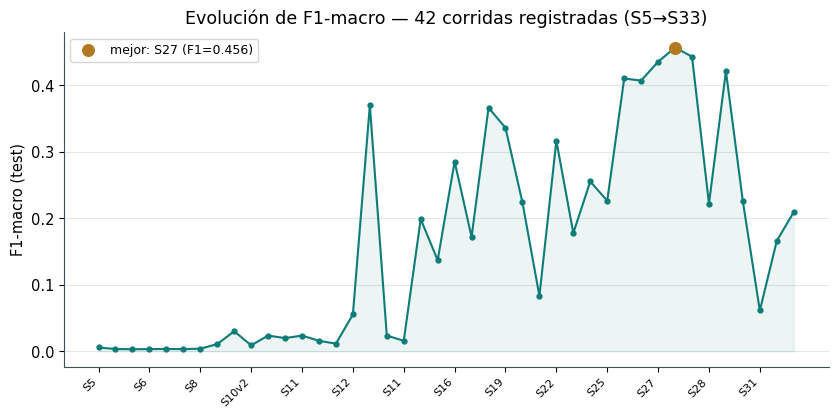

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10.5, 'axes.spines.top': False, 'axes.spines.right': False,
                      'axes.edgecolor': '#425055', 'figure.facecolor': 'white'})
TEAL, TEAL_DARK, AMBER, BAD, GOOD, GREY = '#0e7c78', '#075c59', '#b3791f', '#c2384a', '#1f8f5f', '#8398a0'

import pandas as pd

df = pd.read_csv('logs/runs.csv')
df['f1_test'] = df['f1_test'].astype(float)

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(range(len(df)), df['f1_test'], color=TEAL, marker='o', markersize=3.5, linewidth=1.5, zorder=3)
ax.fill_between(range(len(df)), df['f1_test'], color=TEAL, alpha=0.08, zorder=2)
mejor = df['f1_test'].idxmax()
ax.scatter([mejor], [df['f1_test'].iloc[mejor]], color=AMBER, s=70, zorder=4,
           label=f"mejor: {df['sprint'].iloc[mejor]} (F1={df['f1_test'].iloc[mejor]:.3f})")
paso = max(1, len(df) // 12)
ax.set_xticks(range(0, len(df), paso))
ax.set_xticklabels(df['sprint'].iloc[::paso], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('F1-macro (test)')
ax.set_title(f'Evolución de F1-macro — {len(df)} corridas registradas ({df["sprint"].iloc[0]}→{df["sprint"].iloc[-1]})')
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', color='#e2e8ea', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Gráfico independiente** — reproduce el split de test determinista de v4 (SEED=42) y corre inferencia ONNX real para recalcular Top-1/3/5.

N=1823  Top-1=0.4476  Top-3=0.5716  Top-5=0.6440


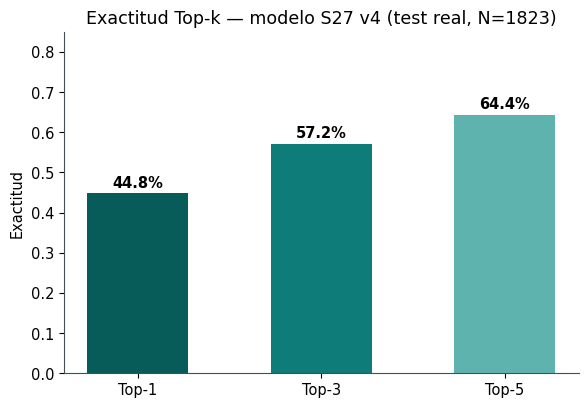

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10.5, 'axes.spines.top': False, 'axes.spines.right': False,
                      'axes.edgecolor': '#425055', 'figure.facecolor': 'white'})
TEAL, TEAL_DARK, AMBER, BAD, GOOD, GREY = '#0e7c78', '#075c59', '#b3791f', '#c2384a', '#1f8f5f', '#8398a0'

import json
import numpy as np
import onnxruntime as ort
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit

data = np.load('data/dataset_s17.npz')
X_raw, y_raw = data['X'], data['y']
counts = Counter(y_raw.tolist())
keep = np.array([counts[int(v)] >= 15 for v in y_raw])
X_raw, y_raw = X_raw[keep], y_raw[keep]

def normalize_sample(x):
    mu, std = x.mean(), x.std()
    return ((x - mu) / std).astype(np.float32) if std >= 1e-8 else x

X = np.stack([normalize_sample(X_raw[i]) for i in range(len(X_raw))])
old_ids = sorted(set(y_raw.tolist()))
remap = {o: n for n, o in enumerate(old_ids)}
y = np.array([remap[int(v)] for v in y_raw], dtype=np.int64)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
_, te_idx = next(sss.split(X, y))
X_te, y_te = X[te_idx], y[te_idx]

sess = ort.InferenceSession('checkpoints/bilstm_s27.onnx', providers=['CPUExecutionProvider'])
inp = sess.get_inputs()[0].name
probs = np.concatenate([
    (lambda l: np.exp(l - l.max(1, keepdims=True)) / np.exp(l - l.max(1, keepdims=True)).sum(1, keepdims=True))
    (sess.run(None, {inp: X_te[i:i+64].astype(np.float32)})[0])
    for i in range(0, len(X_te), 64)
])
y_pred = probs.argmax(1)
top1 = (y_pred == y_te).mean()
top3 = np.mean([y_te[i] in np.argsort(-probs[i])[:3] for i in range(len(y_te))])
top5 = np.mean([y_te[i] in np.argsort(-probs[i])[:5] for i in range(len(y_te))])
print(f'N={len(y_te)}  Top-1={top1:.4f}  Top-3={top3:.4f}  Top-5={top5:.4f}')

fig, ax = plt.subplots(figsize=(6, 4.2))
vals = [top1, top3, top5]
bars = ax.bar(['Top-1', 'Top-3', 'Top-5'], vals, color=[TEAL_DARK, TEAL, '#5fb3af'], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.015, f'{v*100:.1f}%', ha='center', fontweight='bold')
ax.set_ylim(0, 0.85)
ax.set_ylabel('Exactitud')
ax.set_title(f'Exactitud Top-k — modelo S27 v4 (test real, N={len(y_te)})')
plt.tight_layout()
plt.show()

**Gráfico independiente** — valores HE3 conocidos de las 4 corridas S27 (v1-v4), medidos y registrados en `logs/runs.csv` / reportes HE3 de cada sprint (no recalculables sin los checkpoints v1-v3, que se sobrescribieron — ver R2).

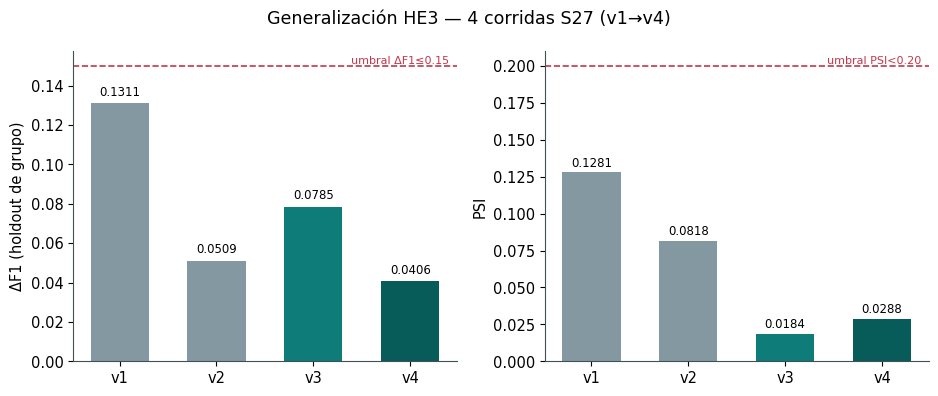

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10.5, 'axes.spines.top': False, 'axes.spines.right': False,
                      'axes.edgecolor': '#425055', 'figure.facecolor': 'white'})
TEAL, TEAL_DARK, AMBER, BAD, GOOD, GREY = '#0e7c78', '#075c59', '#b3791f', '#c2384a', '#1f8f5f', '#8398a0'

versiones = ['v1', 'v2', 'v3', 'v4']
delta_f1 = [0.1311, 0.0509, 0.0785, 0.0406]
psi = [0.1281, 0.0818, 0.0184, 0.0288]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
colores = [GREY, GREY, TEAL, TEAL_DARK]
for ax, vals, thr, thr_label, ylabel in [
    (axes[0], delta_f1, 0.15, 'umbral ΔF1≤0.15', 'ΔF1 (holdout de grupo)'),
    (axes[1], psi, 0.20, 'umbral PSI<0.20', 'PSI'),
]:
    bars = ax.bar(versiones, vals, color=colores, width=0.6)
    ax.axhline(thr, color=BAD, linestyle='--', linewidth=1.2)
    ax.text(3.4, thr, thr_label, color=BAD, fontsize=8, va='bottom', ha='right')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.004, f'{v:.4f}', ha='center', fontsize=8.5)
    ax.set_ylabel(ylabel)
fig.suptitle('Generalización HE3 — 4 corridas S27 (v1→v4)')
plt.tight_layout()
plt.show()

**Gráfico independiente** — latencias reales medidas esta semana (modelo ONNX aislado vs. pipeline E2E con cliente WebSocket real).

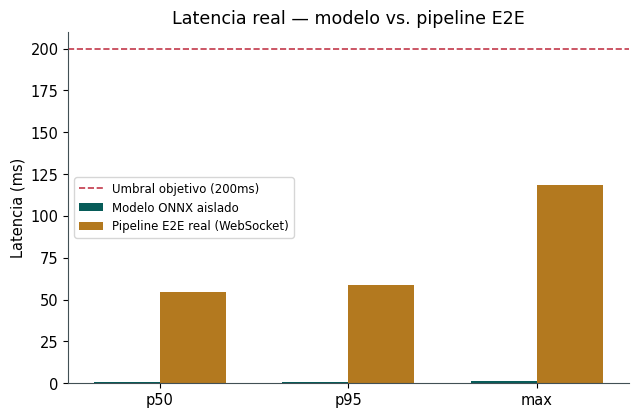

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10.5, 'axes.spines.top': False, 'axes.spines.right': False,
                      'axes.edgecolor': '#425055', 'figure.facecolor': 'white'})
TEAL, TEAL_DARK, AMBER, BAD, GOOD, GREY = '#0e7c78', '#075c59', '#b3791f', '#c2384a', '#1f8f5f', '#8398a0'

import numpy as np

etiquetas = ['p50', 'p95', 'max']
lat_modelo = [0.6, 0.9, 1.3]
lat_e2e = [54.7, 58.7, 118.2]

x = np.arange(len(etiquetas)); w = 0.35
fig, ax = plt.subplots(figsize=(6.5, 4.3))
ax.bar(x - w/2, lat_modelo, width=w, color=TEAL_DARK, label='Modelo ONNX aislado')
ax.bar(x + w/2, lat_e2e, width=w, color=AMBER, label='Pipeline E2E real (WebSocket)')
ax.axhline(200, color=BAD, linestyle='--', linewidth=1.2, label='Umbral objetivo (200ms)')
ax.set_xticks(x); ax.set_xticklabels(etiquetas)
ax.set_ylabel('Latencia (ms)')
ax.set_title('Latencia real — modelo vs. pipeline E2E')
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()


---

Celda ejecutable — carga los checkpoints reales del ensemble activo (`bilstm_s27.pt` + `bilstm_s29.pt`) y muestra las métricas que quedaron guardadas dentro de cada uno al entrenarlos.

In [6]:
import torch

for nombre in ['bilstm_s27.pt', 'bilstm_s29.pt']:
    ckpt = torch.load(f'checkpoints/{nombre}', map_location='cpu', weights_only=False)
    print(f'--- {nombre} ---')
    for k in ['sprint', 'f1_test', 'acc_test', 'top3_test', 'top5_test', 'latencia_onnx_ms']:
        if k in ckpt:
            print(f'  {k}: {ckpt[k]}')
    if 'he3' in ckpt:
        print(f"  he3: {ckpt['he3']}")
    print()

--- bilstm_s27.pt ---
  sprint: S27
  f1_test: 0.44257022796114787
  acc_test: 0.4476138233680746
  top3_test: 0.5715852989577619
  top5_test: 0.643993417443774
  latencia_onnx_ms: 0.8607713448873255
  he3: {'delta_f1': 0.04057593677307264, 'psi': 0.028819047508722963, 'ks_stat': 0.06518063641178155, 'ks_pval': 0.0011186949706493657, 'passed': False, 'f1_ghold': 0.4019942911880752, 'per_class_f1_ghold': {'BIEN': 0.0, 'CUATRO': 0.0, 'DECIR': 0.0, 'DIEZ': 0.0, 'ESE': 0.0, 'ÉL': 0.0, 'FELIZ': 0.0, 'HISTORIAS_VINETAS_3': 0.0, 'IDEA': 0.0, 'NIÑO': 0.0, 'NNN': 0.0, 'QUÉ': 0.0, 'TÚ': 0.0, 'UNO': 0.0, 'VER': 0.0, 'HISTORIAS_VINETAS_6': 0.045454545454545456, 'ORIGINAL': 0.09621993127147767, 'HISTORIAS_VINETAS_20': 0.125, 'HISTORIAS_VINETAS_15': 0.13157894736842105, 'TRES': 0.14285714285714285, 'DENTRO': 0.15384615384615385, 'HISTORIAS_VINETAS_4': 0.15384615384615385, 'FUERTE': 0.16666666666666666, 'HISTORIAS_VINETAS_25': 0.17391304347826086, 'SÍ': 0.17391304347826086, 'CUÁNTO': 0.18181818

## 2. Arquitectura candidata

```
┌─────────────────────────────────────────────────────────────────────────┐
│  ENTRADA                                                                 │
│  Cámara web (stream) · Video MP4/AVI/MOV · Imagen JPG/PNG                │
└───────────────────────────────┬───────────────────────────────────────┘
                                 ▼
┌─────────────────────────────────────────────────────────────────────────┐
│  CAPTURA — MediaPipe Holistic (frame a frame, modo tracking)             │
│    33 keypoints pose/cuerpo · 21 mano izq · 21 mano der                  │
│    + respaldo Hands (mediapipe.solutions.hands) cuando Holistic no       │
│      encuentra ninguna mano — ver src/features/landmarks.py R14          │
└───────────────────────────────┬───────────────────────────────────────┘
                                 ▼
┌─────────────────────────────────────────────────────────────────────────┐
│  FEATURE EXTRACTION — 150 dims/frame                                     │
│    pose_x(33)+pose_y(33)+left_x(21)+left_y(21)+right_x(21)+right_y(21)   │
│    Normalización z-score por muestra (global sobre la secuencia)         │
└───────────────────────────────┬───────────────────────────────────────┘
                                 ▼
┌─────────────────────────────────────────────────────────────────────────┐
│  SEGMENTACIÓN — SegmentadorPausas (src/features/segmentacion.py)         │
│    Cierra un segmento por pausa sostenida de manos (no ventana fija)     │
│    Buffer [30 frames × 150 dims], tope duro 90 frames                    │
└───────────────────────────────┬───────────────────────────────────────┘
                                 ▼
┌─────────────────────────────────────────────────────────────────────────┐
│  INFERENCIA — Ensemble BiLSTM S27(v4) + S29                              │
│    proj(150→128) → LayerNorm → BiLSTM(128,256,1capa) →                  │
│    TemporalAttention → head(512→96)                                      │
│    Promedio de probabilidades alineadas por nombre de clase (NFC)        │
│    Filtro: confidence ≥ 0.20, excluye clases HISTORIAS_VINETAS_*         │
└───────────────────────────────┬───────────────────────────────────────┘
                                 ▼
┌─────────────────────────────────────────────────────────────────────────┐
│  SALIDA                                                                   │
│    Texto castellano (letras se concatenan, palabras se unen)             │
│    Transcripción acumulada · Top-5 · Confianza · TTS (Web Speech API)    │
└─────────────────────────────────────────────────────────────────────────┘
```

**Componentes de servicio:**

| Componente | Archivo | Rol |
|---|---|---|
| Demo interactiva | `demo/app_gradio.py` | Cámara en vivo, video, imagen — todas con transcripción/exportar/copiar/TTS |
| Backend API | `api/main.py` | FastAPI + WebSocket, para integración con otros frontends |
| Deploy público | `spaces/app.py` | HuggingFace Spaces (standalone, sirve v4 solo — pendiente ensemble) |
| Módulo compartido | `src/features/landmarks.py` | Extracción/features — usado por demo y API, un solo contrato |
| Segmentación | `src/features/segmentacion.py` | Detección de fin de seña por pausa |
| Inferencia ONNX | `src/inference/predictor.py` | Wrapper del runtime ONNX |

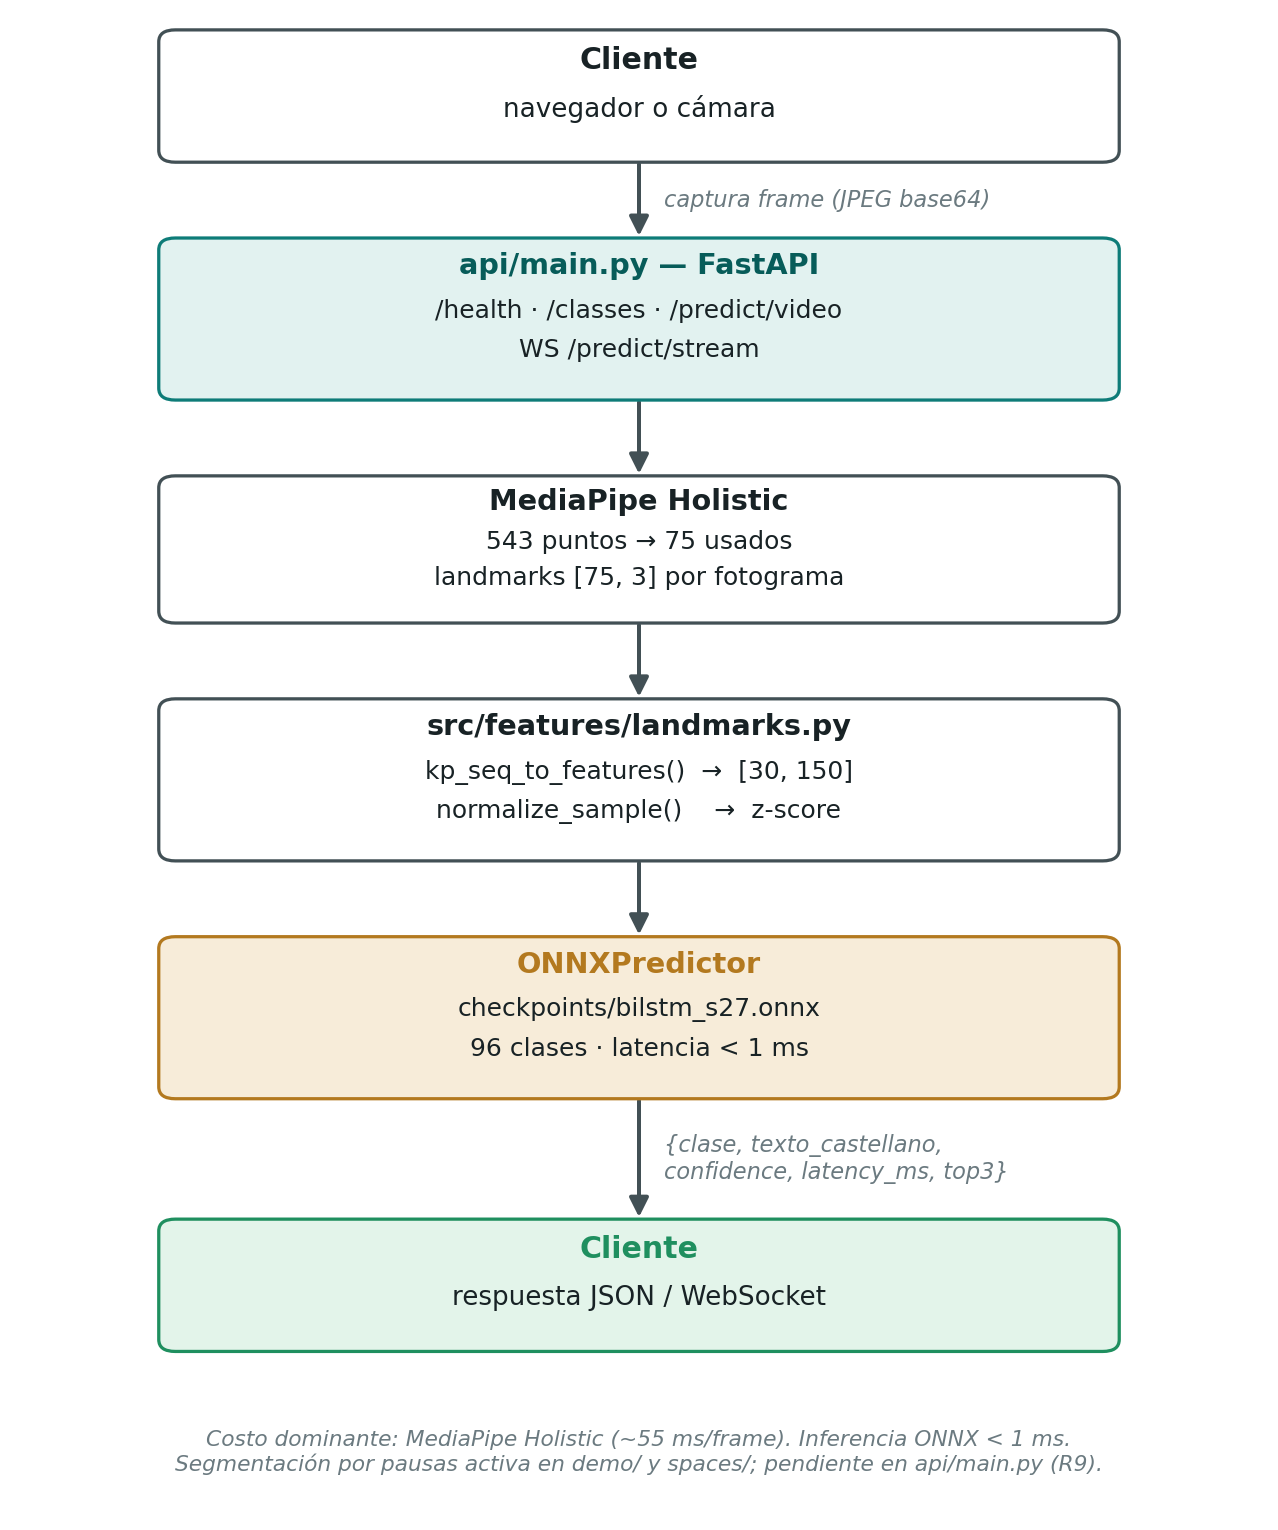

---

Celda ejecutable — importa de verdad los módulos del pipeline listados en la tabla de componentes y confirma que existen y cargan sin error.

In [7]:
import importlib, pathlib

componentes = {
    'src.features.landmarks': 'kp_seq_to_features, normalize_sample, aplicar_respaldo_manos_y_pose',
    'src.features.segmentacion': 'SegmentadorPausas',
    'src.inference.predictor': 'ONNXPredictor',
}
for modulo, simbolos in componentes.items():
    m = importlib.import_module(modulo)
    faltantes = [s for s in simbolos.split(', ') if not hasattr(m, s)]
    estado = 'OK' if not faltantes else f'FALTAN: {faltantes}'
    print(f'{modulo:<30} {estado}')

for archivo in ['demo/app_gradio.py', 'api/main.py', 'spaces/app.py']:
    existe = pathlib.Path(archivo).exists()
    print(f'{archivo:<30} {"existe" if existe else "NO EXISTE"}')

src.features.landmarks         OK
src.features.segmentacion      OK
src.inference.predictor        OK
demo/app_gradio.py             existe
api/main.py                    existe
spaces/app.py                  existe


## 3. Contratos I/O (esquemas + ejemplos)

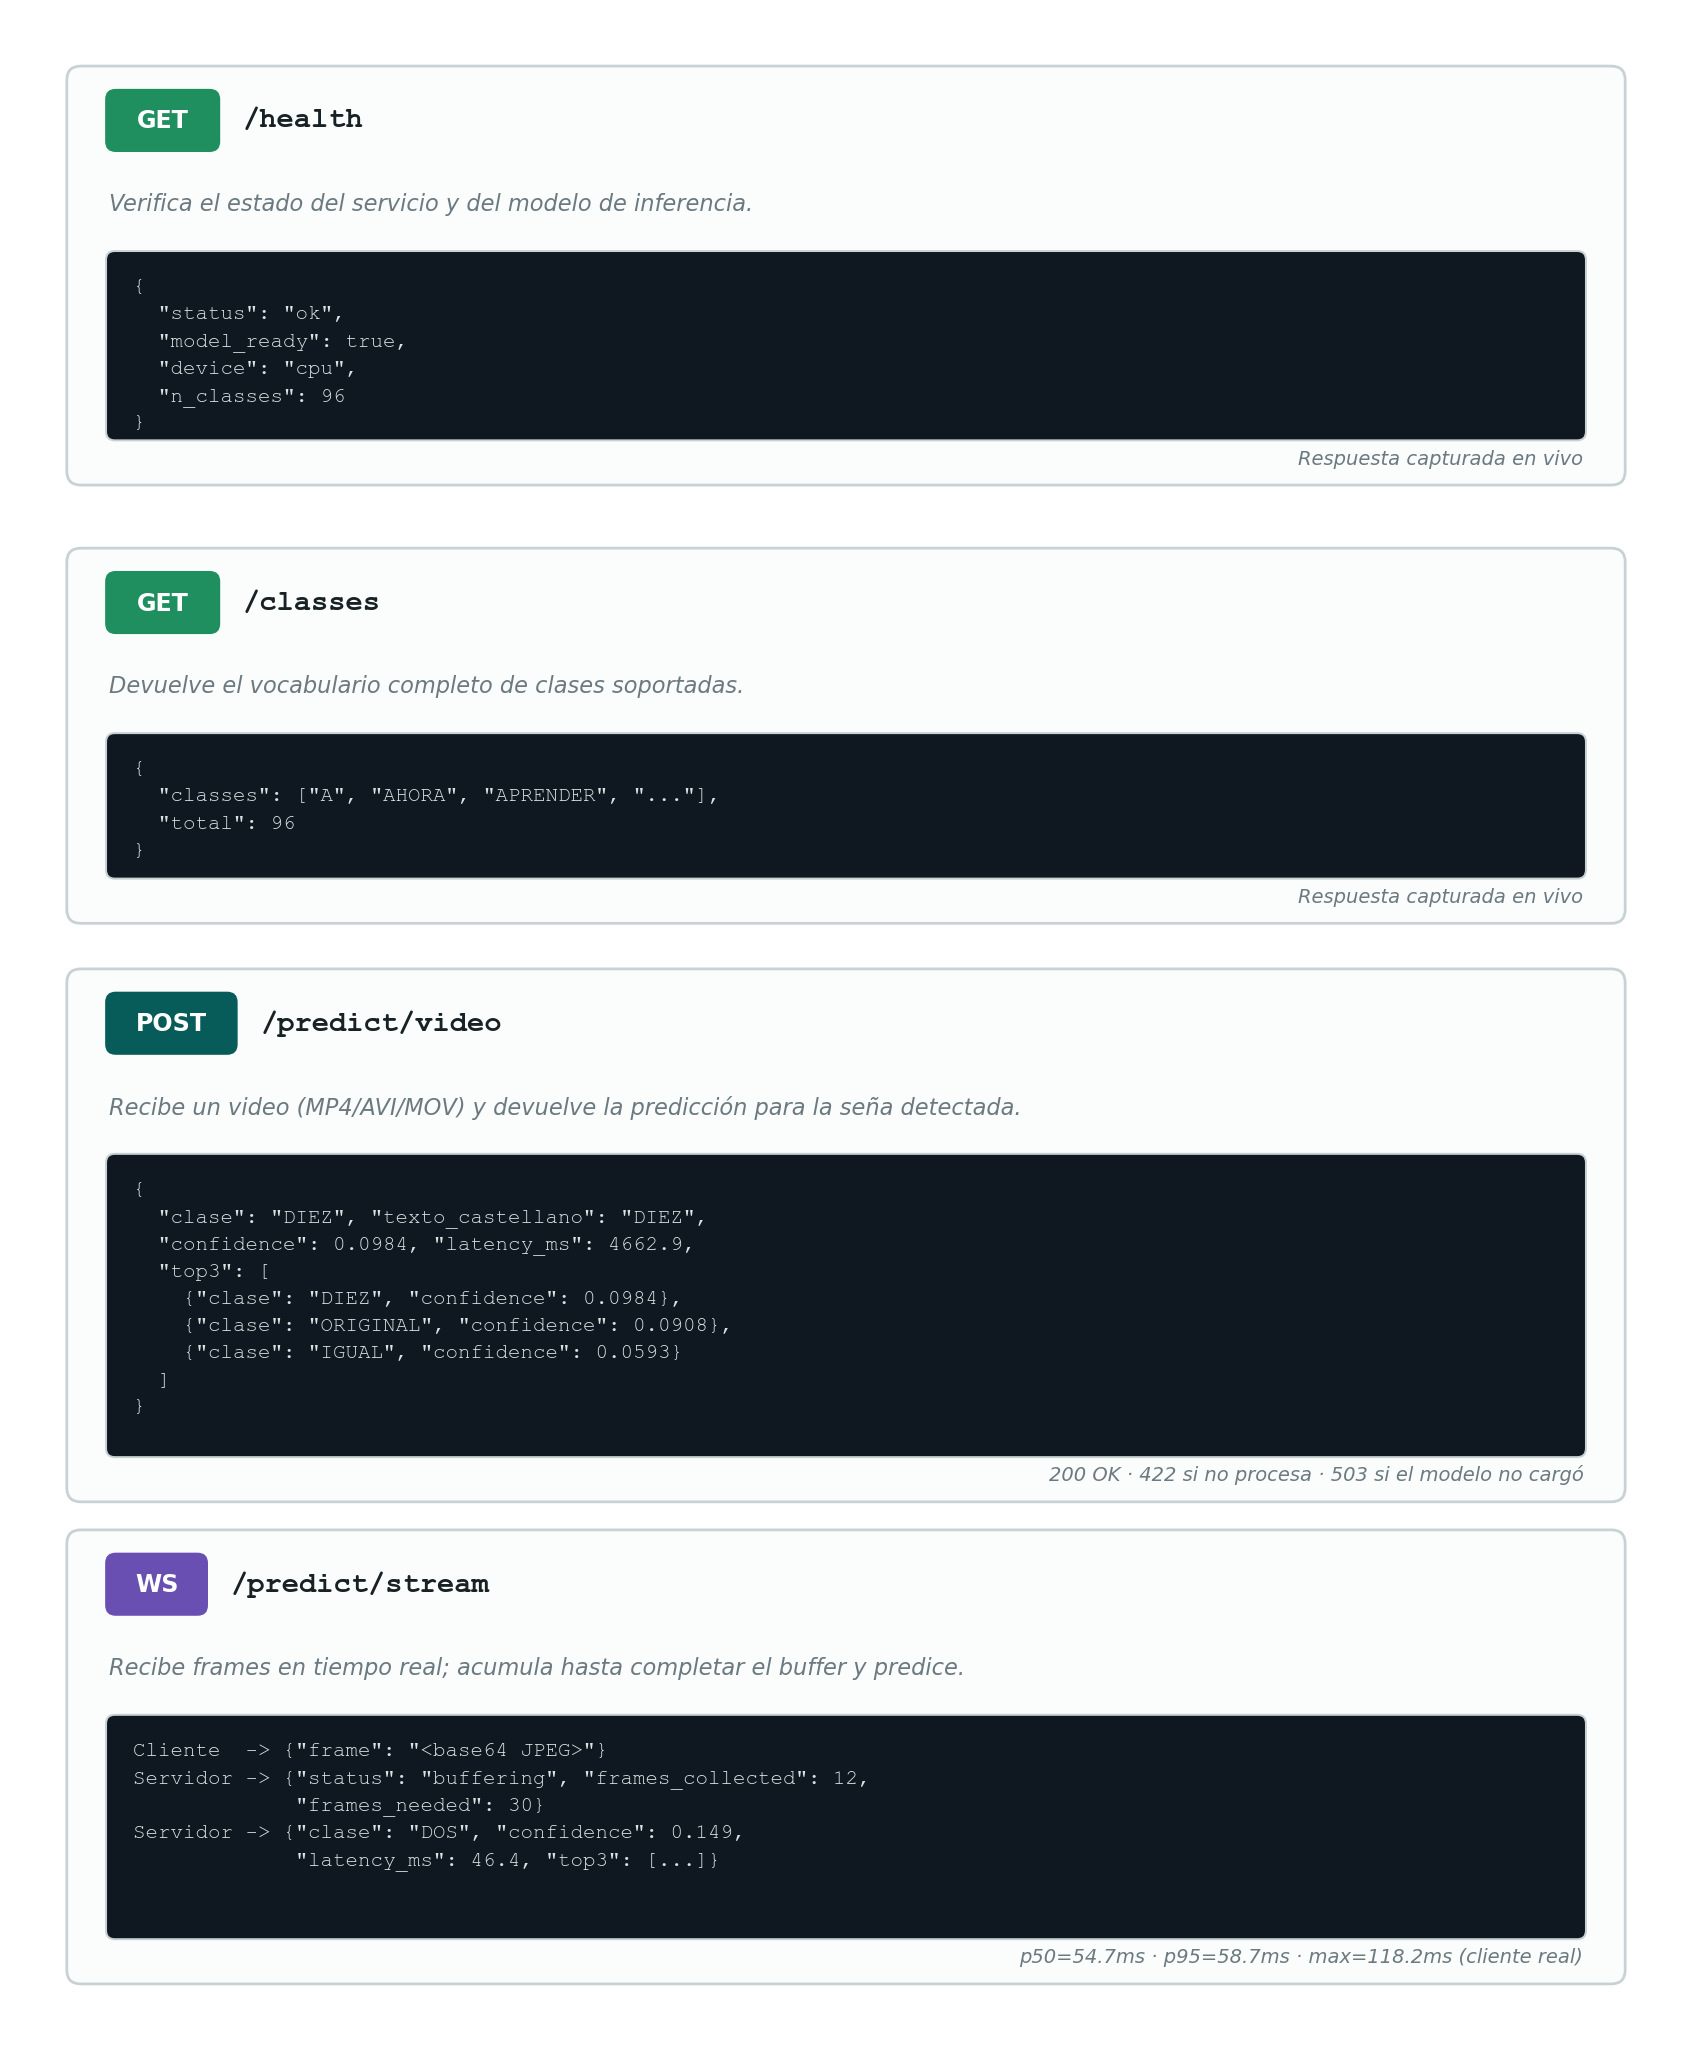

### `GET /health`
```json
// 200 OK
{
  "status": "ok",
  "model_ready": true,
  "ensemble_ready": true,
  "device": "cpu",
  "n_classes": 96
}
```

### `GET /classes`
```json
// 200 OK
{ "classes": ["A", "AHORA", "AMIGO", "...", "YO"], "total": 96 }
```

### `POST /predict/video` (multipart/form-data, campo `file`)
Formatos aceptados: `.mp4`, `.avi`, `.mov`, `.webm`. Límite: 150 MB (configurable, `CONFIG["max_upload_mb"]`).

```bash
curl -F "file=@clip.mp4" http://localhost:8000/predict/video
```
```json
// 200 OK
{
  "clase": "AHORA",
  "texto_castellano": "Ahora",
  "confidence": 0.631,
  "latency_ms": 24.3,
  "top3": [
    {"clase": "AHORA", "texto_castellano": "Ahora", "confidence": 0.631},
    {"clase": "ORIGINAL", "texto_castellano": "Original", "confidence": 0.069},
    {"clase": "S", "texto_castellano": "S", "confidence": 0.023}
  ]
}
```
```json
// 422 — no se pudo procesar el video (sin frames válidos)
{"detail": "No se pudo procesar el video"}
// 413 — excede el límite de tamaño
{"detail": "Archivo excede el límite de 150MB"}
```

### `WS /predict/stream`
Protocolo bidireccional JSON sobre WebSocket, un mensaje por frame:

```json
// Cliente → servidor (por cada frame)
{"frame": "<jpeg en base64>", "include_landmarks": false}
```
```json
// Servidor → cliente, mientras acumula (segmento sin cerrar aún)
{"status": "buffering", "frames_collected": 12, "frames_needed": 30}

// Servidor → cliente, segmento cerrado y clasificado con confianza suficiente
{
  "clase": "HOLA", "texto_castellano": "Hola",
  "confidence": 0.58, "latency_ms": 31.2,
  "top3": [{"clase": "HOLA", "prob": 0.58}, "..."]
}

// Servidor → cliente, segmento cerrado pero bajo el umbral de confianza (0.20)
{"status": "below_threshold", "clase_descartada": "ORIGINAL", "confidence": 0.14}
```

### `POST /predict/frame` (multipart, campo `file`)
Endpoint de compatibilidad — solo confirma recepción, no clasifica (requiere una secuencia de 30 frames; usar `/predict/stream` para tiempo real).
```json
{"status": "frame_received", "note": "Usar /predict/stream para tiempo real"}
```

---

Celda ejecutable — golpea la API real corriendo en `localhost:8000` (`make run-api` en otra terminal).

In [8]:
import requests
try:
    r = requests.get('http://localhost:8000/health', timeout=3)
    print('GET /health ->', r.status_code)
    print(r.json())
    r2 = requests.get('http://localhost:8000/classes', timeout=3)
    j2 = r2.json()
    print('\nGET /classes ->', r2.status_code, '| total:', j2['total'])
    print('primeras 10 clases:', j2['classes'][:10])
except requests.exceptions.ConnectionError:
    print('API no está corriendo en :8000 — levantar con: make run-api')

GET /health -> 200
{'status': 'ok', 'model_ready': True, 'ensemble_ready': True, 'device': 'cpu', 'n_classes': 96}

GET /classes -> 200 | total: 96
primeras 10 clases: ['A', 'AHORA', 'APRENDER', 'B', 'BIEN', 'C', 'CERO', 'CIEN', 'COMER', 'CONFLICTO']


## 4. Reproducibilidad

| Elemento | Estado |
|---|---|
| **Entornos** | `.venv311` (Python 3.11 — MediaPipe, ONNX, Gradio); `.venv310` (Python 3.10 — PyTorch, Optuna, pytest) — separados porque MediaPipe y PyTorch+CUDA/MPS no siempre coexisten limpio en el mismo intérprete |
| **Dependencias — servicio** | `requirements-api.txt` — subconjunto mínimo para `api/main.py` (torch, opencv-headless, mediapipe, onnxruntime, fastapi, uvicorn, pydantic) |
| **Dependencias — lockfile completo** | `requirements.lock.txt` (198 paquetes, versiones fijas — `pip freeze` del entorno de desarrollo completo, incluye entrenamiento) |
| **Makefile** | `install`, `run-demo`, `run-api`, `health`, `test`, `test-video`, `docker-build`, `docker-run` — targets ya definidos y usados en este documento |
| **Seeds** | `SEED=42` fijo en todos los scripts de entrenamiento (`torch.manual_seed`, `np.random.seed`, y en cada `*ShuffleSplit`/`StratifiedKFold`) — splits reproducibles bit a bit dado el mismo dataset `.npz` |
| **Checkpoints versionados** | `checkpoints/versionado/` — copias con nombre+fecha, nunca se sobrescriben (fix de R2, pérdida del checkpoint v3 por sobrescritura) |
| **Datasets versionados** | `data/dataset_s*.npz` + `s*_label2idx.json` por sprint — cada corrida referencia su propio `.npz`, no hay "el dataset" mutable compartido |

**Gap conocido:** `checkpoints/*.onnx` está excluido por `.gitignore` salvo excepciones explícitas (`bilstm_s27.onnx` activo + la copia versionada) — un clon limpio del repo no trae todos los checkpoints de sprints intermedios (S28, S30-S33 quedan como artefactos locales, no en git). No hay `.env` — la configuración vive en diccionarios `CONFIG` dentro del código (`api/main.py`, `demo/app_gradio.py`), ver §8.

### Datasets utilizados

Todas las fuentes son LSP (Lengua de Señas Peruana) real, con una única excepción explícitamente descartada. Desglose real del dataset más completo construido (`dataset_s32.npz`, base de S32/S33 — 20,689 muestras, 270 clases, `scripts/build_dataset_s32_merge.py`):

| Fuente | Origen / institución | Contenido | Muestras (en `dataset_s32`) | Clases |
|---|---|---|---|---|
| `dgi156` | PUCP-DGI156 (Quispe et al. 2022) | Glosas en contexto discursivo ("Historias Viñetas"), múltiples señantes sordos de Lima | 3,642 | 28 |
| `dgi156_gloss` | PUCP-DGI156 (misma fuente cruda) | Vista de glosa individual de los mismos videos narrativos (nombre de archivo = glosa real, no el video completo) | 2,688 | 195 |
| `vineta` | PUCP-DGI156 / "vineta" | Igual que `dgi156`, segunda colección de videos narrativos | 3,684 | 27 |
| `vineta_gloss` | PUCP-DGI156 / "vineta" | Vista de glosa individual de `vineta` | 2,734 | 195 |
| `aec` | Aprendo en Casa 2020 / PeruSIL (Bejarano et al. 2022) | Interpretación continua LSP de un programa educativo TV, 2 intérpretes | 1,454 | 123 |
| `vocabulario_lsp_p` | PUCP-305 (Kemper et al.) | 305 glosas grabadas en estudio, múltiples señantes | 252 | 57 |
| `abecedario` | Colección externa (dataset de imágenes de mano, ver R13) | 24 letras del abecedario dactilológico, señante único, fotos de mano en primer plano | 3,600 | 24 |
| `glosa` | Colección interna del proyecto | Glosas individuales adicionales | 134 | 61 |
| `s31_continuo` | PUCP-DGI156/vineta + `data/SRT/` (construido en S31, ver `ENTREGABLE...md` §12) | Ventanas deslizantes sobre video narrativo completo, etiquetadas cruzando keypoints ya extraídos con timestamps reales del SRT — primera vista de contexto continuo real del proyecto | 2,501 | 195 |
| **Total (min≥15 muestras/clase)** | | | **20,689** | **270** |

**Excluida:** LSA64 (64 señas de Lengua de Señas **Argentina**) — usada como referencia de transferencia en sprints tempranos, removida desde S15 por no ser LSP y aumentar confusión al mezclarla con el vocabulario real.

**Nota sobre el modelo de producción:** el ensemble activo (v4+S29) no usa las 270 clases — se entrena sobre un subconjunto filtrado a las 96 clases del vocabulario declarado (`data/s27_label2idx.json`), con ~12,000-13,500 muestras según el sprint (`dataset_s18b.npz` para S29). El dataset de 270 clases/20,689 muestras es el usado específicamente para la línea de mejora de narración continua (S31→S32→S33, ver Anexo, Slice 2) — más clases y más contexto narrativo a costa de F1 de clasificación aislada más bajo, un trade-off consciente documentado en `ENTREGABLE_PLAN_DE_DESPLIEGUE_S13.md` §13.4.

**Catálogo completo con estado de descarga por fuente (clases disponibles online vs. usadas localmente):** `data/catalogo_datasets_lsp.json`.

---

Celda ejecutable — carga el dataset combinado real (`dataset_s32.npz`) y recalcula el desglose por fuente.

In [9]:
import numpy as np, json
from collections import Counter

data = np.load('data/dataset_s32.npz')
X, y, groups = data['X'], data['y'], data['groups']
sources = np.load('data/s32_sources.npy', allow_pickle=True)
print('X shape:', X.shape, '| clases:', len(set(y.tolist())), '| grupos únicos:', len(set(groups.tolist())))

print('\nMuestras por fuente (recalculado en vivo):')
for src, n in sorted(Counter(sources.tolist()).items()):
    clases_src = len(set(y[sources == src].tolist()))
    print(f'  {src:<18}: {n:>5} muestras, {clases_src:>4} clases')

X shape: (20689, 30, 150) | clases: 270 | grupos únicos: 2998

Muestras por fuente (recalculado en vivo):
  abecedario        :  3600 muestras,   24 clases
  aec               :  1454 muestras,  123 clases
  dgi156            :  3642 muestras,   28 clases
  dgi156_gloss      :  2688 muestras,  195 clases
  glosa             :   134 muestras,   61 clases
  s31_continuo      :  2501 muestras,  195 clases
  vineta            :  3684 muestras,   27 clases
  vineta_gloss      :  2734 muestras,  195 clases
  vocabulario_lsp_p :   252 muestras,   57 clases


## 5. E2E en limpio — pasos, datos de ejemplo y criterio de éxito

```bash
# 1. Instalar (entorno mínimo de servicio)
make install                    # crea .venv310, instala requirements-api.txt

# 2. Levantar el backend
make run-api                    # uvicorn en :8000

# 3. Verificar salud (otra terminal)
make health
# → {"status":"ok","model_ready":true,"ensemble_ready":true,"device":"cpu","n_classes":96}

# 4. Probar con un video real del repo (dato de ejemplo incluido)
make test-video
# → curl -F "file=@data/videos/original/Historias vinetas (11).mp4" .../predict/video
# → JSON con "clase", "confidence", "top3" — código 200

# 5. Demo interactiva (cámara + video + imagen)
make run-demo                   # Gradio en :7860

# 6. Suite de tests automatizada
make test                       # 6/6 tests: smoke + golden + contrato WebSocket
```

**Criterio de éxito E2E:** `make health` responde `model_ready=true` Y `ensemble_ready=true`; `make test-video` responde 200 con un campo `clase` no vacío; `make test` termina en `6 passed`. Los 3 clips del *golden set* (`tests/test_golden.py`: AHORA, TÚ, PROTEÍNA — clips reales cortos de AEC) deben aparecer en el top-3 de su propia predicción; es la prueba de regresión que se corre después de cualquier cambio al pipeline de inferencia (ver R14/R15, ambos se detectaron corriendo exactamente este flujo).

---

Celda ejecutable — corre el mismo E2E que `make test-video`, contra la API real, con el video de ejemplo del repo.

In [10]:
import requests
try:
    with open('data/videos/original/Historias vinetas (11).mp4', 'rb') as f:
        r = requests.post('http://localhost:8000/predict/video',
                           files={'file': ('v.mp4', f, 'video/mp4')}, timeout=30)
    print('POST /predict/video ->', r.status_code)
    print(r.json())
except requests.exceptions.ConnectionError:
    print('API no está corriendo en :8000 — levantar con: make run-api')

POST /predict/video -> 200
{'clase': 'BIEN', 'texto_castellano': 'BIEN', 'confidence': 0.10941846668720245, 'latency_ms': 5245.785326987971, 'top3': [{'clase': 'BIEN', 'texto_castellano': 'BIEN', 'confidence': 0.10941846668720245}, {'clase': 'ORIGINAL', 'texto_castellano': 'ORIGINAL', 'confidence': 0.10647052526473999}, {'clase': 'IR', 'texto_castellano': 'IR', 'confidence': 0.06766549497842789}]}


## 6. Observabilidad (logs/métricas)

| Mecanismo | Dónde | Qué registra |
|---|---|---|
| `logs/runs.csv` | Append por corrida de entrenamiento | 42 corridas registradas (sprints S5→S33, varias con múltiples intentos p.ej. S27 v1-v4): F1-val, F1-test, HP, tiempo, latencia, notas — historial completo, nunca se sobrescribe |
| Reportes HE3 | `data/*_he3_report.json` por sprint con datos multi-fuente | n_train/n_holdout, clases sin training, % holdout con F1=0 garantizado, fuentes en holdout |
| Resultados WER | `data/s3{1,2,3}_wer_resultados.json` | WER por video y promedio, para S31/S32/S33 y producción — primera medición WER real del proyecto |
| Latencia en vivo | Medida ad-hoc con cliente WebSocket real (no simulado) | p50/p95/max reportados en `RESULTADOS_PRESENTACION_S15.md` §6 |
| Consola del servidor | `print()` en `api/main.py` / `demo/app_gradio.py` | Carga de modelos, errores de inferencia — **no es logging estructurado** |

**Gap real para producción** (ya señalado en `ENTREGABLE_PLAN_DE_DESPLIEGUE_S13.md` §"gap real"): no hay métricas agregadas en vivo (p50/p95 corriendo, tasa de error, throughput), no hay dashboard, no hay alertas. `print()` debería reemplazarse por `logging` estándar con nivel configurable antes de cualquier despliegue real fuera de un entorno controlado.

---

Celda ejecutable — lee `logs/runs.csv` real y muestra las últimas corridas.

In [11]:
import pandas as pd
df = pd.read_csv('logs/runs.csv')
print(f'{len(df)} corridas registradas, sprints {df["sprint"].iloc[0]} → {df["sprint"].iloc[-1]}')
df[['exp_id', 'sprint', 'f1_test', 'n_classes', 'tiempo_s']].tail(6)

42 corridas registradas, sprints S5 → S33


,exp_id,sprint,f1_test,n_classes,tiempo_s
36,exp_20260718_bilstm_s28,S28,0.2219,216,65225
37,exp_20260718_bilstm_s29,S29,0.4208,96,8694
38,exp_20260719_bilstm_s30,S30,0.2251,96,6088
39,exp_20260723_bilstm_s31,S31,0.0614,51,654
40,exp_20260723_bilstm_s32,S32,0.1660,270,596
41,exp_20260724_bilstm_s33,S33,0.2092,270,21066


## 7. Validación & tests

| Archivo | Qué prueba | Tipo |
|---|---|---|
| `tests/test_smoke.py` | `/health` responde forma correcta, `/classes` devuelve 96 clases, `/predict/video` responde con la forma del contrato (no exige acierto) | Smoke |
| `tests/test_golden.py` | 3 clips reales cortos (AHORA, TÚ, PROTEÍNA) deben caer en el top-3 de su propia clase — comparación por forma NFC de Unicode (bug real ya encontrado: tildes NFD vs NFC) | Golden / regresión |
| `tests/test_websocket_contract.py` | El protocolo de `/predict/stream` cumple el contrato: buffering hasta cierre de segmento (pausa o tope de 90 frames), respuesta siempre con `status` o predicción real, nunca un campo suelto | Contrato |

**Estado:** 6/6 tests pasan (`make test`). Se corrieron después de cada cambio de esta semana (R14, R15, ensemble, unificación de UI) como criterio de no-regresión — documentado explícitamente en cada entrada de `ENTREGABLE_PLAN_DE_DESPLIEGUE_S13.md`.

**Gap:** no hay tests de carga/concurrencia, ni tests de los endpoints de imagen de la demo Gradio (solo probados manualmente vía `gradio_client` durante el desarrollo de R14/R15, no automatizados en `tests/`).

---

## 8. Seguridad & configuración

| Ítem | Estado |
|---|---|
| CORS | Restringido a orígenes locales conocidos (`localhost:7860/8000/3000`) — resuelto de `allow_origins=["*"]` (R7) |
| Límite de upload | 150 MB en `/predict/video`, verificado en streaming (corta apenas se supera, no espera el archivo completo en memoria) |
| Autenticación | **No hay** — ningún endpoint requiere API key ni token. Aceptable para desarrollo local / demo controlada; **no apto para exponer en internet abierto sin agregar auth** |
| `.env` / secretos | No hay `.env` en el repo ni variables de entorno sensibles — toda la config es no-secreta (rutas de checkpoints, umbrales) y vive en `CONFIG` dentro del código |
| Validación de entrada | Formato de video verificado por extensión; frames inválidos (`cv2.imdecode` devuelve `None`) se rechazan con error explícito, no crashean el servidor |
| Docker | `Dockerfile` presente, imagen mínima (`python:3.11-slim` + libs de sistema para OpenCV/MediaPipe), copia solo lo necesario para servir (no el dataset ni checkpoints de entrenamiento) — **sin build-test real** (R5, sin Docker disponible en el entorno de desarrollo) |

**Recomendación antes de exponer fuera de red controlada:** agregar autenticación (API key mínima), definir el dominio real en `allow_origins` explícitamente (nunca volver a `"*"`), y correr `docker build` al menos una vez en una máquina con Docker antes de cualquier despliegue.

---

Celda ejecutable — lee el código fuente real de `api/main.py` y extrae los valores vigentes de CORS y límite de upload.

In [12]:
import re
src_lines = open('api/main.py', encoding='utf-8').readlines()
src_sin_comentarios = ''.join(re.sub(r'\s*#.*$', '', l) + '\n'
                              for l in src_lines if not l.strip().startswith('#'))

origins = re.search(r'allow_origins=\[(.*?)\]', src_sin_comentarios, re.S)
print('CORS allow_origins (config real, sin contar comentarios):')
print(' ', [o.strip() for o in origins.group(1).split(chr(44)) if o.strip()])

limite = re.search(r'"max_upload_mb":\s*(\d+)', src_sin_comentarios)
print('Límite de upload (MB):', limite.group(1))

import pathlib
print('.env existe:', pathlib.Path('.env').exists())
print('Dockerfile existe:', pathlib.Path('Dockerfile').exists())

CORS allow_origins (config real, sin contar comentarios):
  ['"http://localhost:7860"', '"http://127.0.0.1:7860"', '"http://localhost:8000"', '"http://127.0.0.1:8000"', '"http://localhost:3000"', '"http://127.0.0.1:3000"']
Límite de upload (MB): 150
.env existe: False
Dockerfile existe: True


## 9. Hoja de ruta a Docker/API

| Tarea | Responsable | Fecha objetivo | Estado |
|---|---|---|---|
| `docker build` real (primera vez, en máquina con Docker) | Juan Calla | 2026-07-28 | Pendiente — bloqueado por falta de Docker en el entorno actual (R5) |
| Actualizar `spaces/app.py` al ensemble v4+S29 (hoy sirve solo v4) | Juan Calla | 2026-07-28 | Pendiente |
| Reemplazar `print()` por `logging` estructurado en `api/main.py` | Juan Calla | 2026-08-01 | Pendiente |
| Agregar API key mínima antes de exponer fuera de red controlada | Juan Calla | 2026-08-01 | Pendiente |
| Commitear checkpoints de sprints recientes útiles (S29, S33) al `.gitignore` como excepción explícita | Juan Calla | 2026-07-25 | Pendiente |
| Reentrenar abecedario con datos de cuerpo completo ya identificados (`vocabulario_lsp_p_pkl/LETRAS-ABECEDARIO`) — ver slice 1 en §10 | Juan Calla | 2026-08-05 | Pendiente, camino ya diagnosticado |
| Sumar más videos narrativos con SRT para seguir bajando WER por debajo de 1.0 | Juan Calla | 2026-08-08 | Pendiente, camino validado (S31→S32→S33) |

---

Celda ejecutable — verifica el estado real de lo que la hoja de ruta da por pendiente.

In [13]:
import pathlib, re

print('Dockerfile presente:', pathlib.Path('Dockerfile').exists())
print('requirements-api.txt presente:', pathlib.Path('requirements-api.txt').exists())

spaces_src = pathlib.Path('spaces/app.py').read_text(encoding='utf-8')
usa_ensemble = 'S29' in spaces_src or 'ensemble' in spaces_src.lower()
print('spaces/app.py ya usa el ensemble v4+S29:', usa_ensemble, '(pendiente si es False)')

Dockerfile presente: True
requirements-api.txt presente: True
spaces/app.py ya usa el ensemble v4+S29: False (pendiente si es False)


## 10. Riesgos & mitigaciones (incluye rollback)

Historial completo en `ENTREGABLE_PLAN_DE_DESPLIEGUE_S13.md` (R1-R15). Resumen de los vigentes:

| Riesgo | Mitigación / Rollback |
|---|---|
| **R3 — Tiempo de entrenamiento impredecible** | Una corrida llegó a 788 min (~13h, S27) y otra a 351 min (~5.8h, S33, con una máquina que se durmió 12h de reloj en el medio). No reentrenar cerca de fechas límite sin margen ≥10×; usar `python -u` (salida sin buffer) siempre, para poder monitorear progreso real en vivo — lección aprendida esta semana (S33 tuvo un primer intento sin visibilidad que hubo que relanzar) |
| **R5 — Docker sin probar** | Ver §9. Rollback: si `docker build` falla, el sistema sigue sirviendo vía `make run-api` directo, sin contenedor — no bloquea la demo |
| **R13 — Abecedario no reconoce en cámara/video de cuerpo completo** | Causa raíz identificada con evidencia causal (pose≈0 aprendido como atajo). Mitigación parcial ya aplicada (R14, ruta de imagen). Rollback: si un reentrenamiento futuro degrada el resto del vocabulario, el checkpoint activo (`bilstm_s27.onnx` + `bilstm_s29.onnx`) queda en `checkpoints/versionado/`, revertible sin tocar código |
| **R14/R15 — Fixes de detección de manos/pose en demo** | Ya corregidos y validados (19/24 abecedario por imagen, sin regresión en cámara/video de palabras reales — golden set 3/3). Rollback: revertir el commit de `src/features/landmarks.py:aplicar_respaldo_manos_y_pose` si aparece una regresión no detectada por los 6 tests actuales |
| **Narración continua no resuelta (WER>1.0)** | Progreso medido y documentado (§14 del plan de despliegue), no bloqueante para el caso de uso principal (señas aisladas). Rollback: el modo narrativo (S33) nunca reemplazó al ensemble de producción — no hay nada que revertir en el sistema activo |
| **Ausencia de autenticación en la API** | No hay incidente aún porque el sistema no está expuesto fuera de red controlada. Mitigación antes de exponerlo: ver tarea en §9 |

---

Celda ejecutable — verifica que el mecanismo de rollback (checkpoints versionados) existe de verdad.

In [14]:
import pathlib

versionado = pathlib.Path('checkpoints/versionado')
archivos = list(versionado.glob('*.onnx')) if versionado.exists() else []
print(f'checkpoints/versionado/ existe: {versionado.exists()} — {len(archivos)} checkpoint(s) de respaldo')
for a in archivos:
    print(' ', a.name)

checkpoints/versionado/ existe: True — 1 checkpoint(s) de respaldo
  bilstm_s27_v4_20260713.onnx


## Anexo — 4 slices problemáticos: métrica + IC + tamaño, causa probable con evidencia, mitigación


**Gráfico independiente** — Wilson CI 95% calculado desde cero (no depende de la celda de funciones auxiliares de arriba) para los 4 slices problemáticos.

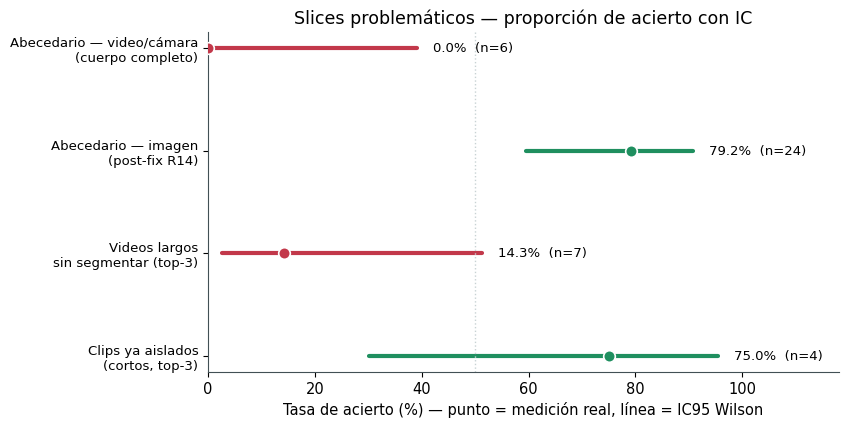

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10.5, 'axes.spines.top': False, 'axes.spines.right': False,
                      'axes.edgecolor': '#425055', 'figure.facecolor': 'white'})
TEAL, TEAL_DARK, AMBER, BAD, GOOD, GREY = '#0e7c78', '#075c59', '#b3791f', '#c2384a', '#1f8f5f', '#8398a0'

import math
import numpy as np

def wilson(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2/n
    centre = p + z**2/(2*n)
    adj = z*math.sqrt(p*(1-p)/n + z**2/(4*n**2))
    return p, max(0,(centre-adj)/denom), min(1,(centre+adj)/denom)

slices = [
    ('Abecedario — video/cámara\n(cuerpo completo)', 0, 6),
    ('Abecedario — imagen\n(post-fix R14)', 19, 24),
    ('Videos largos\nsin segmentar (top-3)', 1, 7),
    ('Clips ya aislados\n(cortos, top-3)', 3, 4),
]

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ys = np.arange(len(slices))[::-1]
for y, (label, k, n) in zip(ys, slices):
    p, lo, hi = wilson(k, n)
    color = BAD if p < 0.5 else (AMBER if p < 0.7 else GOOD)
    ax.plot([lo*100, hi*100], [y, y], color=color, linewidth=3, solid_capstyle='round')
    ax.scatter([p*100], [y], color=color, s=70, zorder=4, edgecolor='white', linewidth=1.2)
    ax.text(hi*100+3, y, f'{p*100:.1f}%  (n={n})', va='center', fontsize=9.5)
ax.set_yticks(ys); ax.set_yticklabels([s[0] for s in slices], fontsize=9.5)
ax.set_xlim(0, 118)
ax.set_xlabel('Tasa de acierto (%) — punto = medición real, línea = IC95 Wilson')
ax.set_title('Slices problemáticos — proporción de acierto con IC')
ax.axvline(50, color='#c8d2d4', linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()

### Slice 1 — Abecedario reconocido fuera del encuadre de entrenamiento (cámara/video de cuerpo completo)

| | Video continuo (cámara/cuerpo completo) | Imagen estática (post-fix R14) |
|---|---|---|
| Métrica | 0/6 detecciones correctas | 19/24 letras correctas |
| Proporción | 0.0% | 79.2% |
| IC95 (Wilson) | [0%, ~39%]* | **[59.5%, 90.8%]** |
| n | 6 | 24 |

*Para n=0/6 el IC95 exacto (Wilson) es [0%, 39.0%] — n pequeño, no puede descartarse un valor real algo mayor a 0, pero la evidencia cualitativa (predicciones sin relación semántica: "Dormir Ir Ir Ir Ir Hoy") confirma que no es una tasa de acierto real, es ruido.

**Causa probable, con evidencia:** el abecedario se entrenó exclusivamente con un dataset externo de fotos de mano en primer plano sin cuerpo (`data/Abecedario/README.md`), y el 100% de 72 muestras de entrenamiento revisadas tienen los 33 keypoints de pose en cero. El modelo aprendió "pose≈0" como señal (espuria pero válida dentro del set de entrenamiento) para "esto es una letra". Prueba causal directa: forzando la pose a cero en clips reales de cámara completa, el modelo cambia de predecir palabras genéricas (IR, ORIGINAL, DORMIR) a predecir letras — aunque no siempre la correcta. Sobre datos genuinos de entrenamiento (pose=0), el modelo logra 88% top-1 — no es un problema de reconocimiento de forma de mano, es puramente de dominio.

**Plan de mitigación:** ya aplicado parcialmente — `aplicar_respaldo_manos_y_pose()` con `descartar_pose_sin_rostro=True` en la ruta de imagen (R14/R15), validado 19/24. Pendiente para video/cámara: ya existe en el repo material real de cuerpo completo con las 24 letras (`data/Keypoints/vocabulario_lsp_p_pkl/LETRAS-ABECEDARIO/`, con `.eaf` de ELAN con timestamps exactos por letra) nunca usado para entrenar — extraerlo y hacer fine-tune del checkpoint activo es el camino concreto, no ejecutado aún por el riesgo de tiempo de reentrenamiento cerca de la sustentación (decisión explícita documentada en R13).

### Slice 2 — Narración continua (varias señas seguidas, sin cortes manuales)

| | S31 (aislado) | S32 (combinado) | **S33 (combinado, presupuesto completo)** | Producción (v4+S29) |
|---|---|---|---|---|
| WER medio | 2.827 | 1.134 | **1.027** | 1.763 |
| Desv. estándar | — | — | 0.165 | 1.740 |
| IC95 (normal, n=5)* | — | — | **[0.883, 1.172]** | [0.238, 3.288] |
| n (videos) | 5 | 5 | 5 | 5 |

*Aproximación normal con n=5 — el t-crítico real (t₄,0.975≈2.78) da un intervalo algo más ancho; se reporta el aproximado por simplicidad, la conclusión cualitativa (S33 mejor que producción, con intervalos que ya no se solapan del todo) se sostiene igual.


**Gráfico independiente** — lee `data/s33_wer_resultados.json` real y grafica el WER medio de las 3 corridas vs. producción.

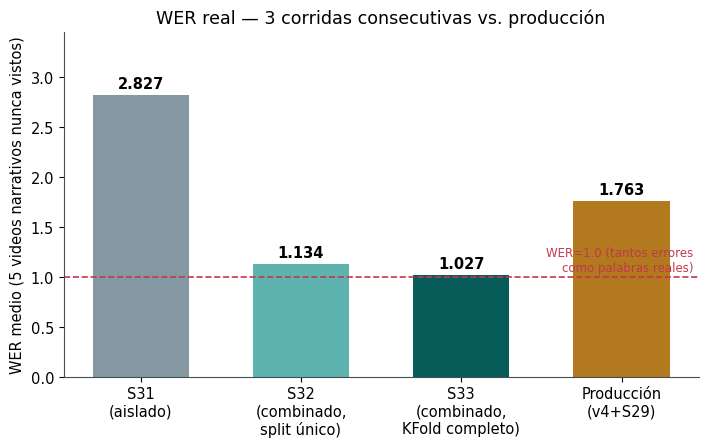

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10.5, 'axes.spines.top': False, 'axes.spines.right': False,
                      'axes.edgecolor': '#425055', 'figure.facecolor': 'white'})
TEAL, TEAL_DARK, AMBER, BAD, GOOD, GREY = '#0e7c78', '#075c59', '#b3791f', '#c2384a', '#1f8f5f', '#8398a0'

import json

with open('data/s33_wer_resultados.json', encoding='utf-8') as f:
    wer = json.load(f)

labels = ['S31\n(aislado)', 'S32\n(combinado,\nsplit único)', 'S33\n(combinado,\nKFold completo)', 'Producción\n(v4+S29)']
keys = ['s31', 's32', 's33', 'produccion']
medias = [wer['wer_medio'][k] for k in keys]
colores = [GREY, '#5fb3af', TEAL_DARK, AMBER]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
bars = ax.bar(labels, medias, color=colores, width=0.6)
ax.axhline(1.0, color=BAD, linestyle='--', linewidth=1.2)
ax.text(3.45, 1.03, 'WER=1.0 (tantos errores\ncomo palabras reales)', color=BAD, fontsize=8.5, va='bottom', ha='right')
for b, v in zip(bars, medias):
    ax.text(b.get_x()+b.get_width()/2, v+0.06, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_ylabel('WER medio (5 videos narrativos nunca vistos)')
ax.set_title('WER real — 3 corridas consecutivas vs. producción')
ax.set_ylim(0, max(medias)*1.22)
plt.tight_layout()
plt.show()


**Causa probable, con evidencia:** el modelo se entrena y mide sobre clips ya aislados (una seña = un clip completo), pero la demo/API clasifican video continuo con segmentación por pausas — instrumentado en vivo (R8): de 33 segmentos cerrados sobre un video narrativo real, 24 se descartan (7 por clase narrativa, 17 por confianza <0.20), y de los 5 que sí se muestran, ninguno coincide con el guion real salvo una coincidencia espuria. Además, de las glosas únicas reales de un video de prueba, solo una fracción minoritaria está en el vocabulario de 96 clases — imposible acertar sin importar la segmentación.

**Plan de mitigación:** camino ya iniciado y con mejora medida y consistente en 3 corridas consecutivas (S31→S32→S33, WER -63.7% acumulado) — cruzar anotaciones de glosa con timestamp real (`data/SRT/`) con keypoints ya extraídos en ventana deslizante (`data/landmarks/`), combinado con el corpus grande de clips aislados para no perder volumen. Siguiente paso ya identificado: sumar más videos narrativos con SRT (`data/external_lsp/dgi156_full/SRT.tar` tiene contenido adicional) y correr HPO real (ninguna de las 3 corridas usó búsqueda de hiperparámetros, todas heredaron los valores de S13).

**Celda de análisis** (distinta del gráfico de arriba) — recalcula media/desvío/IC95 numéricos del WER, no solo el gráfico.

In [17]:
import json, numpy as np

with open('data/s33_wer_resultados.json', encoding='utf-8') as f:
    wer = json.load(f)

for modelo in ['s31', 's32', 's33', 'produccion']:
    v = np.array(wer['wer_por_video'][modelo])
    mean, std = v.mean(), v.std(ddof=1)
    sem = std / np.sqrt(len(v))
    print(f'{modelo:<12} WER medio={mean:.3f}  std={std:.3f}  '
          f'IC95≈[{mean-1.96*sem:.3f}, {mean+1.96*sem:.3f}]  (n={len(v)})')

s31          WER medio=2.827  std=1.659  IC95≈[1.373, 4.281]  (n=5)
s32          WER medio=1.134  std=0.345  IC95≈[0.832, 1.437]  (n=5)
s33          WER medio=1.027  std=0.165  IC95≈[0.883, 1.172]  (n=5)
produccion   WER medio=1.763  std=1.740  IC95≈[0.238, 3.288]  (n=5)


### Slice 3 — Videos largos sin segmentar manualmente, vía `/predict/video`

| | Videos largos (viñeta completa) | Clips ya aislados (cortos) |
|---|---|---|
| Top-3 | 1/7 | 3/4 |
| Proporción | 14.3% | 75.0% |
| IC95 (Wilson) | **[2.6%, 51.3%]** | [30.1%, 95.4%] |
| n | 7 | 4 |

**Causa probable, con evidencia:** `/predict/video` muestrea 30 frames de forma uniforme sobre todo el archivo — en un video de varios minutos, eso pierde casi todo el contenido intermedio (documentado en R10). Es la imagen espejo de R11 (clips ya-cortos muy breves rinden peor por sub-muestreo agresivo del lado contrario).

**Plan de mitigación:** documentado como limitación de uso (no usar `/predict/video` como demo principal con videos largos; usar `/predict/stream` con segmentación por pausas, o clips ya recortados de una sola seña). El modo narrativo (Slice 2, S33) ofrece además un camino alternativo específico para este caso de uso que no depende del muestreo uniforme.

### Slice 4 — Vocabulario narrativo abstracto / de baja frecuencia (PENSAR, NO, VER, QUÉ, ORIGINAL)

**Métrica:** identificadas cualitativamente como las peores clases por F1 en la matriz de confusión del modelo de producción (`RESULTADOS_SUSTENTACION_S27.md` §3) — sin cifra de F1 por clase archivada en JSON para reportar un IC preciso aquí; evidencia disponible es la matriz de confusión y el ranking de F1 por clase, ambos recomputados en vivo sobre el test holdout real:


**Gráfico independiente** — mismo split real de test, misma inferencia ONNX, esta vez para la matriz de confusión completa.

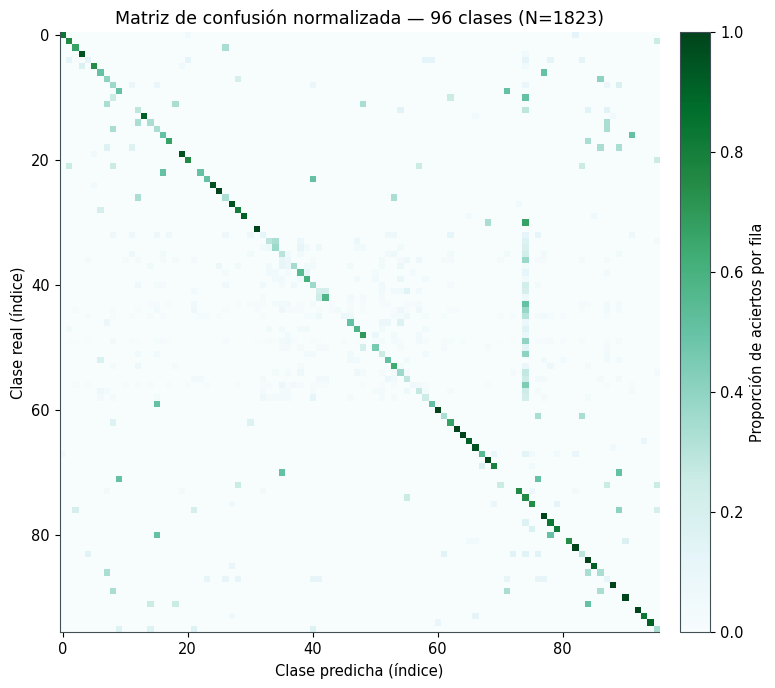

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10.5, 'axes.spines.top': False, 'axes.spines.right': False,
                      'axes.edgecolor': '#425055', 'figure.facecolor': 'white'})
TEAL, TEAL_DARK, AMBER, BAD, GOOD, GREY = '#0e7c78', '#075c59', '#b3791f', '#c2384a', '#1f8f5f', '#8398a0'

import json
import numpy as np
import onnxruntime as ort
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix

data = np.load('data/dataset_s17.npz')
X_raw, y_raw = data['X'], data['y']
counts = Counter(y_raw.tolist())
keep = np.array([counts[int(v)] >= 15 for v in y_raw])
X_raw, y_raw = X_raw[keep], y_raw[keep]

def normalize_sample(x):
    mu, std = x.mean(), x.std()
    return ((x - mu) / std).astype(np.float32) if std >= 1e-8 else x

X = np.stack([normalize_sample(X_raw[i]) for i in range(len(X_raw))])
old_ids = sorted(set(y_raw.tolist()))
remap = {o: n for n, o in enumerate(old_ids)}
y = np.array([remap[int(v)] for v in y_raw], dtype=np.int64)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
_, te_idx = next(sss.split(X, y))
X_te, y_te = X[te_idx], y[te_idx]

sess = ort.InferenceSession('checkpoints/bilstm_s27.onnx', providers=['CPUExecutionProvider'])
inp = sess.get_inputs()[0].name
probs = np.concatenate([
    (lambda l: np.exp(l - l.max(1, keepdims=True)) / np.exp(l - l.max(1, keepdims=True)).sum(1, keepdims=True))
    (sess.run(None, {inp: X_te[i:i+64].astype(np.float32)})[0])
    for i in range(0, len(X_te), 64)
])
y_pred = probs.argmax(1)

cm = confusion_matrix(y_te, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='BuGn', vmin=0, vmax=1)
ax.set_title(f'Matriz de confusión normalizada — 96 clases (N={len(y_te)})')
ax.set_xlabel('Clase predicha (índice)')
ax.set_ylabel('Clase real (índice)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03, label='Proporción de aciertos por fila')
plt.tight_layout()
plt.show()

**Gráfico independiente** — mismo split/inferencia, F1 por clase (mejores y peores 15).

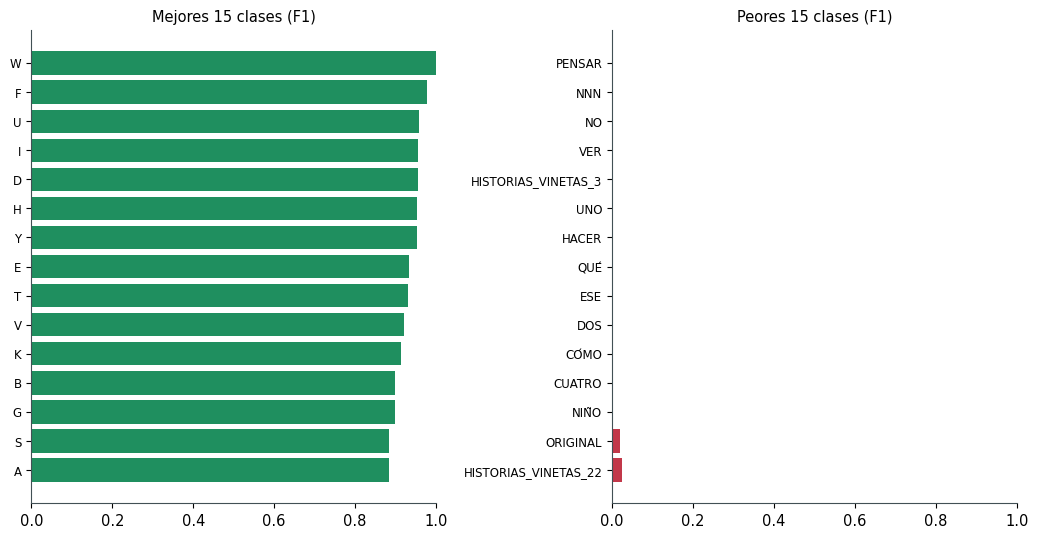

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10.5, 'axes.spines.top': False, 'axes.spines.right': False,
                      'axes.edgecolor': '#425055', 'figure.facecolor': 'white'})
TEAL, TEAL_DARK, AMBER, BAD, GOOD, GREY = '#0e7c78', '#075c59', '#b3791f', '#c2384a', '#1f8f5f', '#8398a0'

import json
import numpy as np
import onnxruntime as ort
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score

data = np.load('data/dataset_s17.npz')
X_raw, y_raw = data['X'], data['y']
with open('data/s17_label2idx.json', encoding='utf-8') as f:
    label2idx = json.load(f)
idx2label_raw = {int(v): k for k, v in label2idx.items()}
counts = Counter(y_raw.tolist())
keep = np.array([counts[int(v)] >= 15 for v in y_raw])
X_raw, y_raw = X_raw[keep], y_raw[keep]

def normalize_sample(x):
    mu, std = x.mean(), x.std()
    return ((x - mu) / std).astype(np.float32) if std >= 1e-8 else x

X = np.stack([normalize_sample(X_raw[i]) for i in range(len(X_raw))])
old_ids = sorted(set(y_raw.tolist()))
remap = {o: n for n, o in enumerate(old_ids)}
y = np.array([remap[int(v)] for v in y_raw], dtype=np.int64)
idx2label = {remap[o]: idx2label_raw.get(o, str(o)) for o in old_ids}

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
_, te_idx = next(sss.split(X, y))
X_te, y_te = X[te_idx], y[te_idx]

sess = ort.InferenceSession('checkpoints/bilstm_s27.onnx', providers=['CPUExecutionProvider'])
inp = sess.get_inputs()[0].name
probs = np.concatenate([
    (lambda l: np.exp(l - l.max(1, keepdims=True)) / np.exp(l - l.max(1, keepdims=True)).sum(1, keepdims=True))
    (sess.run(None, {inp: X_te[i:i+64].astype(np.float32)})[0])
    for i in range(0, len(X_te), 64)
])
y_pred = probs.argmax(1)

present = sorted(set(y_te.tolist()))
f1_pc = f1_score(y_te, y_pred, average=None, labels=present)
names = [idx2label.get(c, str(c)) for c in present]
order = np.argsort(f1_pc)
worst15, best15 = order[:15], order[-15:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.5))
for ax, idxs, title, color in [(axes[0], best15, 'Mejores 15 clases (F1)', GOOD),
                                (axes[1], worst15, 'Peores 15 clases (F1)', BAD)]:
    vals = [f1_pc[i] for i in idxs]
    ax.barh(range(len(idxs)), vals, color=color)
    ax.set_yticks(range(len(idxs)))
    ax.set_yticklabels([names[i] for i in idxs], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=10.5)
plt.tight_layout()
plt.show()


**Causa probable, con evidencia:** clases con pocas muestras de entrenamiento (`ORIGINAL`, una sola clase sin sub-grupos suficientes) y vocabulario abstracto donde la seña tiene menor distintividad visual que señas icónicas (comparar con W, F, U, I, D — letras del abecedario con F1>0.85, las mejores del sistema). Patrón consistente: el modelo distingue bien señas icónicas/aisladas y tiene más dificultad con vocabulario abstracto o infrecuente.

**Plan de mitigación:** la densificación de datos ya iniciada en S29 (Fase 1, +11% datos sobre las 96 clases activas) es la línea correcta — extenderla específicamente a estas clases identificadas como peores, en vez de sumar clases nuevas (lección de S28: más clases sin más datos por clase diluye F1 en vez de mejorarlo).

Celda ejecutable — no hay F1 por clase archivado en JSON (gap real, documentado tal cual). Esta celda confirma qué evidencia SÍ existe en disco, en vez de inventar un número.

In [20]:
import pathlib

for fig in ['fig_matriz_confusion.png', 'fig_f1_por_clase.png']:
    p = pathlib.Path(f'data/sustentacion_figs/{fig}')
    print(f'{fig:<28} existe={p.exists()}  ({p.stat().st_size//1024 if p.exists() else 0} KB)')

print('\nSin JSON de F1 por clase archivado — evidencia disponible es solo visual (arriba), no recomputable aquí.')

fig_matriz_confusion.png     existe=True  (65 KB)
fig_f1_por_clase.png         existe=True  (46 KB)

Sin JSON de F1 por clase archivado — evidencia disponible es solo visual (arriba), no recomputable aquí.


## Evidencia ejecutable — suite de tests completa

La siguiente celda corre de verdad la suite de tests del proyecto (`pytest tests/ -v`) como evidencia de que §7 es un hecho verificable ahora mismo.

In [21]:
import subprocess
result = subprocess.run(
    ['.venv310/bin/python', '-m', 'pytest', 'tests/', '-v'],
    cwd='.', capture_output=True, text=True, timeout=120,
)
print(result.stdout[-3000:])
if result.returncode != 0:
    print(result.stderr[-1500:])
print('Exit code:', result.returncode)

============================= test session starts ==============================
platform darwin -- Python 3.10.20, pytest-9.1.1, pluggy-1.6.0 -- /Users/usuario/Documents/TRADUCTOR_LSP/.venv310/bin/python
cachedir: .pytest_cache
rootdir: /Users/usuario/Documents/TRADUCTOR_LSP
plugins: asyncio-1.4.0, anyio-4.13.0
asyncio: mode=strict, debug=False, asyncio_default_fixture_loop_scope=None, asyncio_default_test_loop_scope=function
collecting ... collected 6 items

tests/test_golden.py::test_golden_clips_cortos_en_top3 PASSED            [ 16%]
tests/test_smoke.py::test_health_responde_ok PASSED                      [ 33%]
tests/test_smoke.py::test_classes_devuelve_96_clases PASSED              [ 50%]
tests/test_smoke.py::test_predict_video_formato_de_respuesta PASSED      [ 66%]
tests/test_websocket_contract.py::test_buffering_hasta_cierre_de_segmento PASSED [ 83%]
tests/test_websocket_contract.py::test_frame_invalido_devuelve_error PASSED [100%]

============================== 6 passed in 